## Fase 1: Demostración del Flujo de Procesamiento (Sujeto Piloto)

Para validar nuestra metodología, ejecutaremos el flujo de trabajo paso a paso utilizando un único registro (Sujeto 1). 

### Paso 1: Selección de datos y canales de interés
Se carga el registro EEG y se aíslan exclusivamente los electrodos asociados a la corteza sensoriomotora (**C3, C4 y Cz**). A continuación, se visualiza un segmento de la señal cruda para evidenciar el nivel de ruido base antes de aplicar cualquier filtro.

Extracting EDF parameters from Sujetos/S001R04.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Canales seleccionados: ['C3', 'C4', 'Cz']
Frecuencia de muestreo: 160.0 Hz
Using matplotlib as 2D backend.


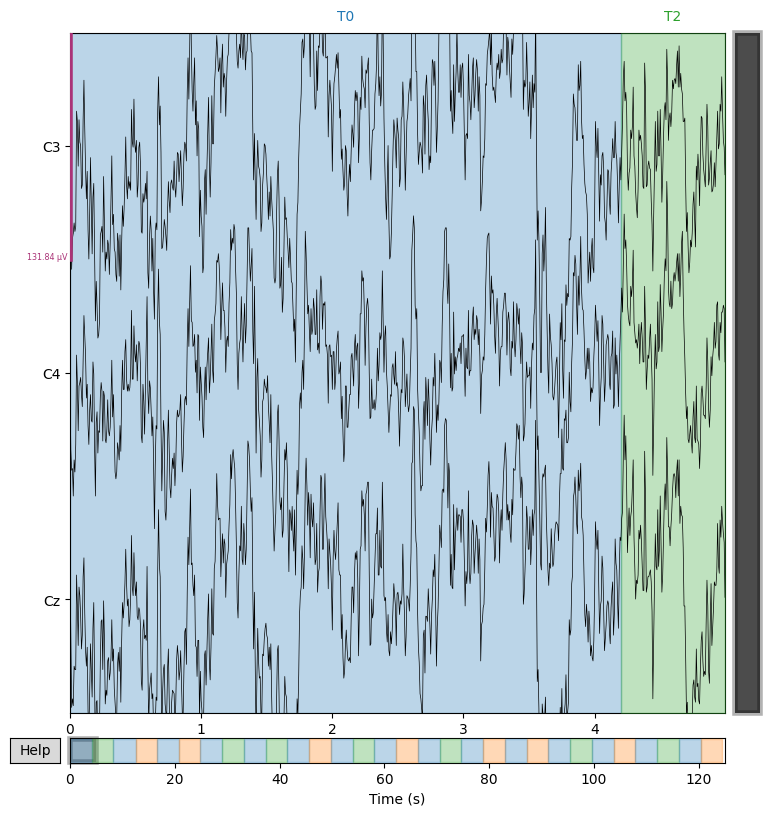

In [ ]:
import mne
import matplotlib.pyplot as plt

# BLOQUE 1: CARGA DE DATOS Y VISUALIZACIÓN CRUDA


# Usamos R04 porque el README indica que ahí está la Tarea 2 (Imaginación motora de puños)
ruta_archivo = 'Sujetos/S001R04.edf' 

# 2. Cargar la señal cruda
# preload=True carga la señal en memoria para poder trabajar con ella
senal_cruda = mne.io.read_raw_edf(ruta_archivo, preload=True)
mne.datasets.eegbci.standardize(senal_cruda)

# 3. Seleccionar los canales de interés
canales_motores = ['C3', 'C4', 'Cz']
senal_cruda.pick_channels(canales_motores)

# Imprimir información básica para verificar
print(f"Canales seleccionados: {senal_cruda.ch_names}")
print(f"Frecuencia de muestreo: {senal_cruda.info['sfreq']} Hz")

# 4. Visualizar 5 segundos de la señal original
# Usamos scalings='auto' para que Python ajuste el tamaño de la onda automáticamente
senal_cruda.plot(duration=5, n_channels=3, title="Bloque 1: Señal Cruda (Con Ruido)", scalings='auto')
plt.show()

<>:57: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:57: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\Juan Esteban\AppData\Local\Temp\ipykernel_5752\1841019233.py:57: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  eje.set_ylabel("Amplitud ($\mu V$)", fontsize=12)


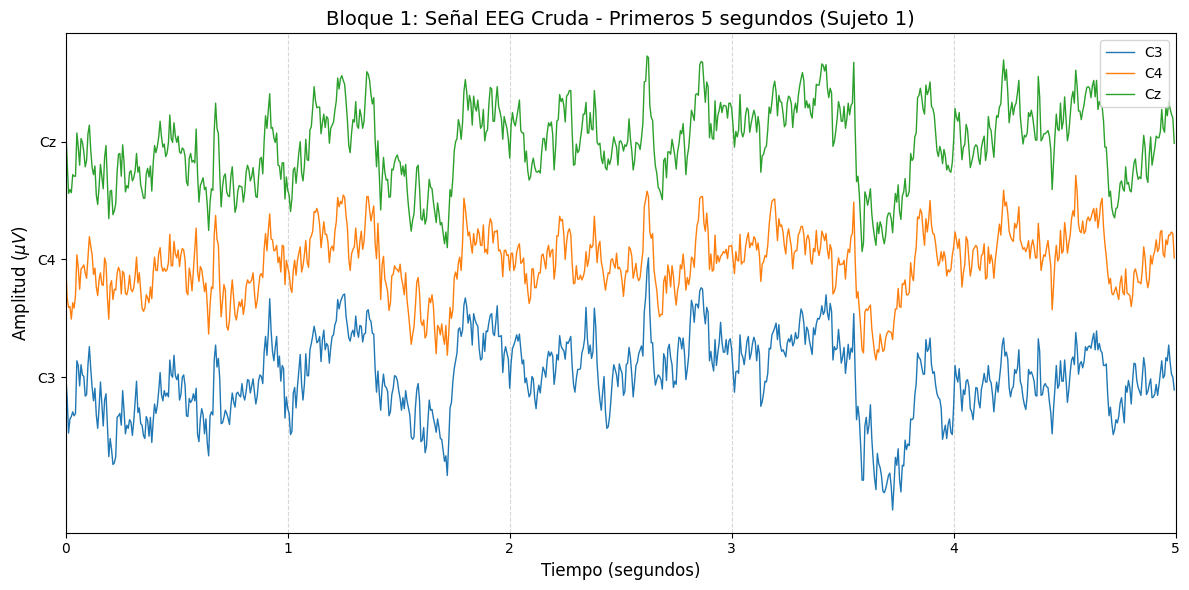

In [ ]:

ruta_archivo = 'Sujetos/S001R04.edf' 

# 2. Cargar la señal cruda (raw)
senal_cruda = mne.io.read_raw_edf(ruta_archivo, preload=True, verbose=False)

# Limpiar nombres de canales
mne.datasets.eegbci.standardize(senal_cruda)

# 3. Seleccionar los canales de interés 
canales_motores = ['C3', 'C4', 'Cz']
senal_cruda.pick(canales_motores)

# Obtener información necesaria para graficar
frecuencia_muestreo = senal_cruda.info['sfreq']
nombres_ch = senal_cruda.ch_names


# --------------------------4. EXTRACCIÓN DE DATOS Y GRAFICADO CON MATPLOTLIB ------------------------------------------------


# Definimos cuántos segundos queremos ver
segundos_inicio = 0
segundos_fin = 5

# Convertimos segundos a índices de la matriz de datos
inicio_idx = int(segundos_inicio * frecuencia_muestreo)
fin_idx = int(segundos_fin * frecuencia_muestreo)

# Extraemos los datos numéricos (matriz numpy) y el vector de tiempo
# get_data devuelve Voltios, los convertimos a Microvoltios (* 1e6)
datos, tiempos = senal_cruda.get_data(start=inicio_idx, stop=fin_idx, return_times=True)
datos_microvoltios = datos * 1e6

# Crear la gráfica con Matplotlib
fig, eje = plt.subplots(figsize=(12, 6))

# Graficamos cada canal con un color distinto
colores = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Azul, Naranja, Verde

for i in range(len(canales_motores)):
    # Graficamos sumando un desplazamiento (offset) para que no se superpongan
    desplazamiento = i * 150 # microvoltios
    eje.plot(tiempos, datos_microvoltios[i] + desplazamiento, 
             color=colores[i], label=canales_motores[i], lw=1)

# Configuraciones estéticas de la gráfica (Ejes en Español)
eje.set_title(f"Bloque 1: Señal EEG Cruda - Primeros {segundos_fin} segundos (Sujeto 1)", fontsize=14)
eje.set_xlabel("Tiempo (segundos)", fontsize=12)
eje.set_ylabel("Amplitud ($\mu V$)", fontsize=12)
eje.set_xlim(segundos_inicio, segundos_fin)

# Ajustar las marcas del eje Y para que muestren los nombres de los canales
eje.set_yticks([0, 150, 300])
eje.set_yticklabels(canales_motores)

eje.grid(axis='x', linestyle='--', alpha=0.5)
eje.legend(loc='upper right')

plt.tight_layout()
plt.show()

### Bloque 2: Preprocesamiento - Filtrado Frecuencial y Comprobación (PSD)

Las señales EEG crudas presentan una baja relación señal-ruido debido a interferencias eléctricas y artefactos biológicos. Dado que los datos fueron registrados en EE. UU., se aplicará un filtro Notch a 60 Hz para eliminar el ruido de la red eléctrica. 

Posteriormente, se aplicará un filtro pasa-banda entre 8 Hz y 30 Hz. Esto nos permite aislar de manera precisa los ritmos sensoriomotores $\mu$ (8-13 Hz) y $\beta$ (14-30 Hz), eliminando derivas de baja frecuencia (como parpadeos) y ruidos de alta frecuencia (como contracciones musculares). 

Para comprobar la eficacia del filtrado, se compara la Densidad Espectral de Potencia (PSD) antes y después del procesamiento.

Plotting power spectral density (dB=True).
Plotting power spectral density (dB=True).


C:\Users\Juan Esteban\AppData\Local\Temp\ipykernel_5752\2461234200.py:22: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  psd_cruda.plot(axes=ejes[0], show=False)
C:\Users\Juan Esteban\AppData\Local\Temp\ipykernel_5752\2461234200.py:28: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  psd_filtrada.plot(axes=ejes[1], show=False)


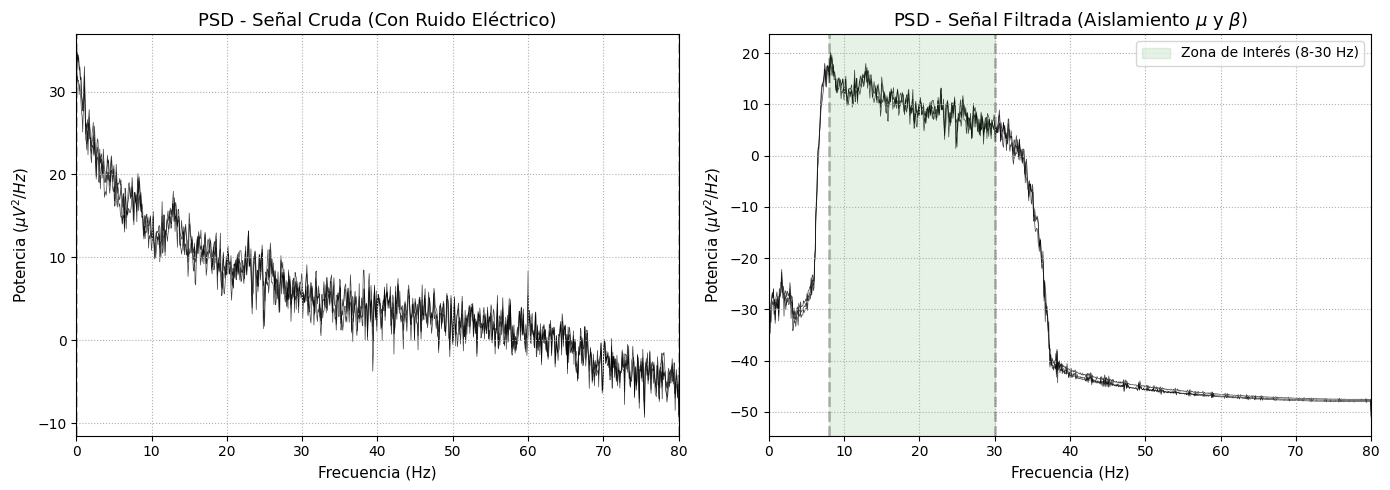

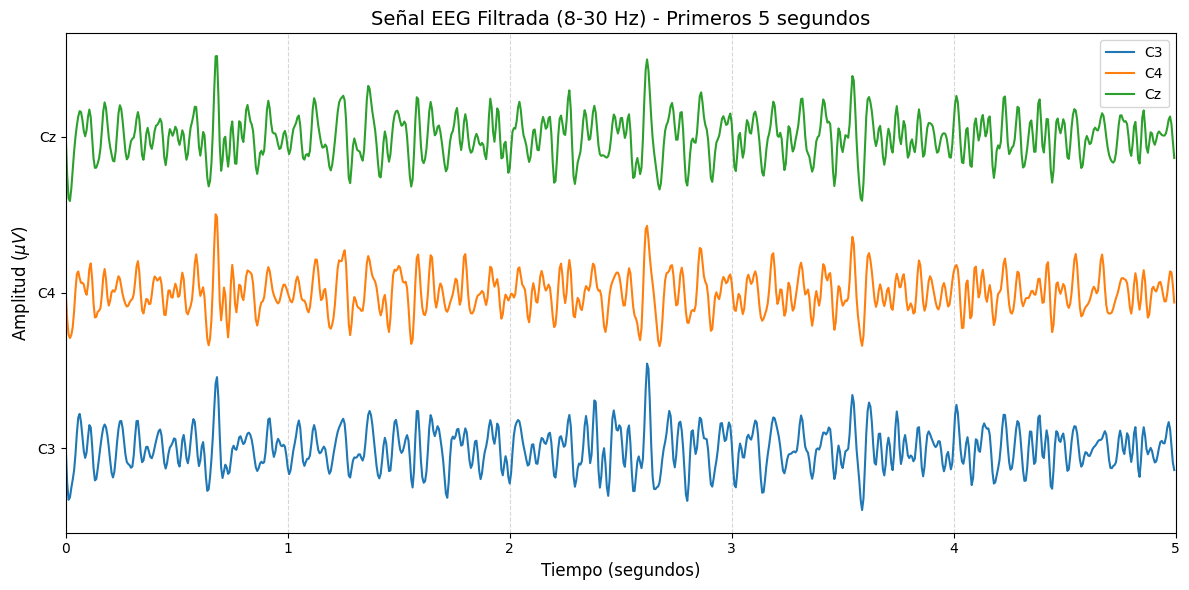

In [ ]:
# ---------------------------BLOQUE 2: FILTRADO Y COMPROBACIÓN VISUAL (PSD) --------------------------------------------------

# 1. Crear una copia de la señal cruda para no alterarla y poder comparar
senal_filtrada = senal_cruda.copy()

# 2. Aplicar Filtro Notch (60 Hz)
senal_filtrada.notch_filter(freqs=60.0, verbose=False)

# 3. Aplicar Filtro Pasa-Banda (8 - 30 Hz)
senal_filtrada.filter(l_freq=8.0, h_freq=30.0, verbose=False)

# 4. Calcular la Densidad Espectral de Potencia (PSD)
psd_cruda = senal_cruda.compute_psd(fmax=80, verbose=False)
psd_filtrada = senal_filtrada.compute_psd(fmax=80, verbose=False)

# 5. Graficar la comparativa (Antes y Después)
fig, ejes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica de la señal con ruido
psd_cruda.plot(axes=ejes[0], show=False)
ejes[0].set_title(r"PSD - Señal Cruda (Con Ruido Eléctrico)", fontsize=13)
ejes[0].set_ylabel(r"Potencia ($\mu V^2/Hz$)", fontsize=11)
ejes[0].set_xlabel("Frecuencia (Hz)", fontsize=11)

# Gráfica de la señal limpia
psd_filtrada.plot(axes=ejes[1], show=False)
ejes[1].set_title(r"PSD - Señal Filtrada (Aislamiento $\mu$ y $\beta$)", fontsize=13)
ejes[1].set_ylabel(r"Potencia ($\mu V^2/Hz$)", fontsize=11)
ejes[1].set_xlabel("Frecuencia (Hz)", fontsize=11)

# Sombrear nuestra zona de interés (8 a 30 Hz)
ejes[1].axvspan(8, 30, color='green', alpha=0.1, label='Zona de Interés (8-30 Hz)')
ejes[1].legend()

plt.tight_layout()
plt.show()

# -------------------------------6. VISUALIZAR LA SEÑAL LIMPIA EN EL TIEMPO --------------------------------------

datos_limpios, tiempos = senal_filtrada.get_data(start=inicio_idx, stop=fin_idx, return_times=True)
datos_limpios_microvoltios = datos_limpios * 1e6

fig2, eje2 = plt.subplots(figsize=(12, 6))

for i in range(len(canales_motores)):
    desplazamiento = i * 150 # microvoltios
    eje2.plot(tiempos, datos_limpios_microvoltios[i] + desplazamiento, 
              color=colores[i], label=canales_motores[i], lw=1.5)

eje2.set_title(r"Señal EEG Filtrada (8-30 Hz) - Primeros 5 segundos", fontsize=14)
eje2.set_xlabel("Tiempo (segundos)", fontsize=12)
eje2.set_ylabel(r"Amplitud ($\mu V$)", fontsize=12)
eje2.set_xlim(segundos_inicio, segundos_fin)
eje2.set_yticks([0, 150, 300])
eje2.set_yticklabels(canales_motores)
eje2.grid(axis='x', linestyle='--', alpha=0.5)
eje2.legend(loc='upper right')

plt.tight_layout()
plt.show()

### Bloque 3: Segmentación de la Señal (Epoching) y Conectividad (Coherencia)

La señal continua de EEG contiene diferentes eventos correspondientes al protocolo experimental. De acuerdo con la documentación del dataset (Wadsworth Center), para la **Tarea 2** (Imaginación motora de puños), los eventos se codifican de la siguiente manera:
* **T0:** Periodo de reposo.
* **T1:** Imaginación del movimiento del puño izquierdo.
* **T2:** Imaginación del movimiento del puño derecho.

Procederemos a extraer estos marcadores y segmentar la señal continua en *epochs* (ventanas de tiempo) que inician 0.5 segundos antes del estímulo y finalizan 4 segundos después. 

Para cumplir con el requerimiento de análisis de conectividad, se calculará la **Coherencia de magnitud al cuadrado** entre los electrodos interhemisféricos (C3 y C4) para un *epoch* específico de imaginación motora, permitiendo observar la sincronización de las áreas motoras izquierda y derecha en el dominio de la frecuencia.

Eventos encontrados en el registro: {'Reposo': 1, 'Imag_Izquierda': 2, 'Imag_Derecha': 3}


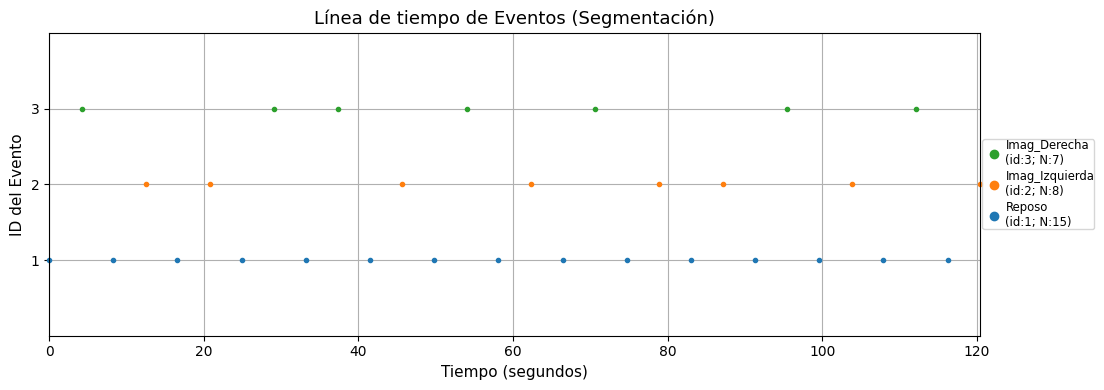

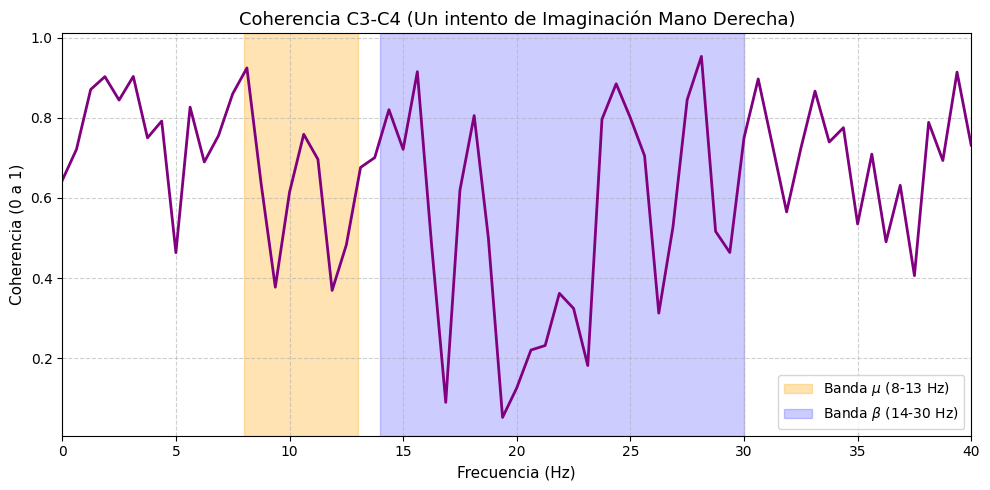

In [ ]:
from scipy.signal import coherence
import matplotlib.pyplot as plt
import mne

# ------------------------------------BLOQUE 3: EPOCHING Y CÁLCULO DE COHERENCIA (CORREGIDO)----------------------------------

# 1. Extraer los eventos (marcadores) de las anotaciones del archivo
eventos, eventos_dict = mne.events_from_annotations(senal_filtrada, verbose=False)

# Mapeamos los nombres técnicos del archivo a un diccionario en Español
mapeo_eventos = {}
for clave, valor in eventos_dict.items():
    if clave == 'T0': mapeo_eventos['Reposo'] = valor
    elif clave == 'T1': mapeo_eventos['Imag_Izquierda'] = valor
    elif clave == 'T2': mapeo_eventos['Imag_Derecha'] = valor

print("Eventos encontrados en el registro:", mapeo_eventos)

# 2. Segmentación (Epoching)
# Cortamos la señal: desde -0.5 seg (antes) hasta 4.0 seg (después del estímulo)
epochs = mne.Epochs(senal_filtrada, eventos, event_id=mapeo_eventos, 
                    tmin=-0.5, tmax=4.0, baseline=(-0.5, 0), 
                    preload=True, verbose=False)

# 3. CÁLCULO DE COHERENCIA PARA UN EVENTO (Aporte del grupo de 3)
# Aislamos todos los intentos donde imaginó mover la mano derecha
epochs_derecha = epochs['Imag_Derecha'].get_data(copy=True)

# Seleccionamos un solo intento (el primer epoch) como ejemplo
epoch_ejemplo = epochs_derecha[0]

# Encontramos en qué posición de la matriz están C3 y C4
idx_c3 = epochs.ch_names.index('C3')
idx_c4 = epochs.ch_names.index('C4')

# Calculamos la Coherencia 
frecuencias_coh, valores_coherencia = coherence(epoch_ejemplo[idx_c3], 
                                                epoch_ejemplo[idx_c4], 
                                                fs=frecuencia_muestreo, 
                                                nperseg=256)

# ----------------------------------- 4. GRAFICACIÓN DE RESULTADOS-----------------------------------

# --- GRÁFICA 1: Línea de tiempo de eventos ---
fig1, ax1 = plt.subplots(figsize=(10, 4))
mne.viz.plot_events(eventos, sfreq=frecuencia_muestreo, first_samp=senal_filtrada.first_samp,
                    event_id=mapeo_eventos, axes=ax1, show=False)

ax1.set_title("Línea de tiempo de Eventos (Segmentación)", fontsize=13)
ax1.set_xlabel("Tiempo (segundos)", fontsize=11)
ax1.set_ylabel("ID del Evento", fontsize=11)

fig1.tight_layout()
plt.show()

# --- GRÁFICA 2: Coherencia interhemisférica ---
fig2, ax2 = plt.subplots(figsize=(10, 5))
ax2.plot(frecuencias_coh, valores_coherencia, color='purple', lw=2)

# Resaltamos nuestras bandas de interés (Mu y Beta)
ax2.axvspan(8, 13, color='orange', alpha=0.3, label=r'Banda $\mu$ (8-13 Hz)')
ax2.axvspan(14, 30, color='blue', alpha=0.2, label=r'Banda $\beta$ (14-30 Hz)')

ax2.set_title(r"Coherencia C3-C4 (Un intento de Imaginación Mano Derecha)", fontsize=13)
ax2.set_xlabel("Frecuencia (Hz)", fontsize=11)
ax2.set_ylabel("Coherencia (0 a 1)", fontsize=11)
ax2.set_xlim(0, 40) # Mostramos solo hasta 40Hz
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

fig2.tight_layout()
plt.show()

### Bloque 4: Extracción de Características, ERD/ERS y Coherencia

En esta fase, transformamos la señal temporal en características en el dominio de la frecuencia. Este proceso se divide en tres partes fundamentales:

1. **Identificación de ERD/ERS (Análisis Tiempo-Frecuencia):** Utilizamos la transformada Wavelet de Morlet para visualizar cómo cambia la potencia espectral a lo largo del tiempo en comparación con el periodo de reposo (*baseline* de -0.5 a 0 s). Una caída en la potencia se conoce como ERD (asociada a la activación motora), y un aumento como ERS.
2. **Densidad Espectral de Potencia (PSD):** Se calcula la potencia absoluta en las bandas de interés ($\mu$: 8-13 Hz y $\beta$: 14-30 Hz) exclusivamente durante la ventana de imaginación motora (0 a 4 segundos).
3. **Características de Coherencia:** Cuantificamos el nivel de sincronización interhemisférica (C3-C4) promedio para cada época en ambas bandas, consolidando el biomarcador de conectividad.

Iniciando extracción de características...
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Applying baseline correction (mode: percent)
Applying baseline correction (mode: percent)


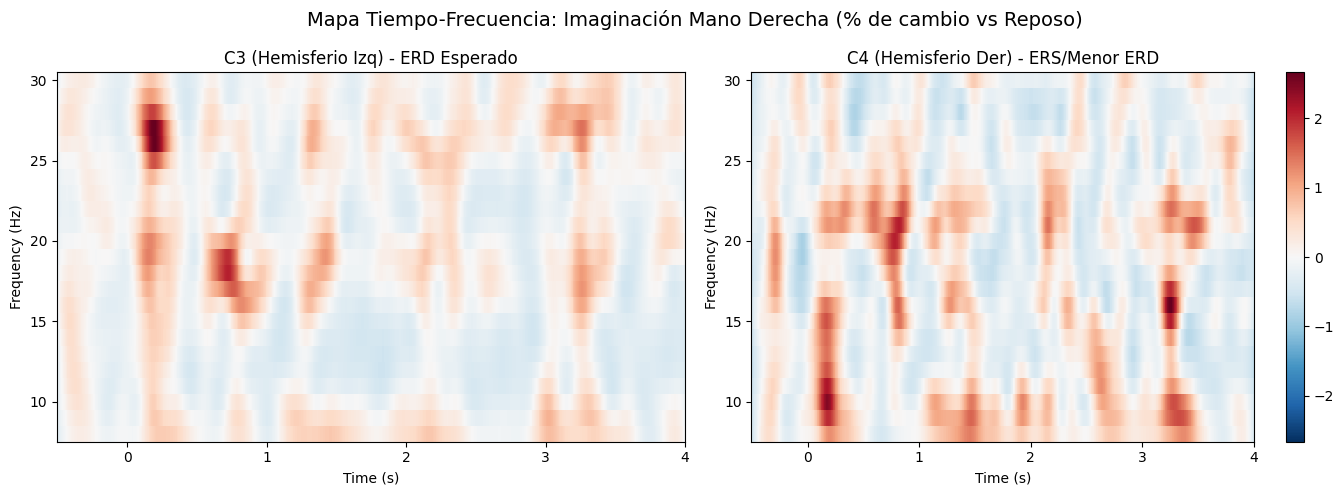


--- Vista previa de las Características Extraídas (Primeros 5 Epochs) ---


,Etiqueta_Tarea,Potencia_Mu_C3,Potencia_Mu_C4,Potencia_Beta_C3,Potencia_Beta_C4,Coherencia_Mu_C3_C4,Coherencia_Beta_C3_C4,Nombre_Tarea
0,3,34.329708,29.330695,8.589974,7.016202,0.627895,0.547068,Imag_Derecha
1,1,37.141557,22.633125,12.700603,8.747275,0.702578,0.673245,Reposo
2,2,19.670462,18.512265,8.945276,5.585484,0.661497,0.615193,Imag_Izquierda
3,1,34.468121,27.324529,7.045237,5.920635,0.374239,0.540017,Reposo
4,2,39.889834,16.428764,7.666166,6.133066,0.729238,0.559130,Imag_Izquierda


In [ ]:
import numpy as np
import pandas as pd
from scipy.signal import coherence
from mne.time_frequency import tfr_morlet

# --------------------------------- BLOQUE 4: ERD/ERS, PSD Y EXTRACCIÓN DE CARACTERÍSTICAS--------------------------------------

print("Iniciando extracción de características...")

# ====================================== PARTE A: VISUALIZACIÓN DE ERD/ERS (MAPAS TIEMPO-FRECUENCIA)=====================================

# Definimos las frecuencias exactas que queremos analizar (8 a 30 Hz)
frecuencias_tfr = np.arange(8, 31, 1)
# El número de ciclos controla el balance entre resolución de tiempo y frecuencia
ciclos = frecuencias_tfr / 2.0 

# Calculamos la Transformada de Wavelet para los intentos de "Mano Derecha"
# return_itc=False porque solo nos interesa la potencia, average=True para promediar todos los intentos
tfr_derecha = tfr_morlet(epochs['Imag_Derecha'], freqs=frecuencias_tfr, 
                         n_cycles=ciclos, return_itc=False, average=True, verbose=False)

# Graficamos el ERD/ERS. 
# mode='percent' aplica la fórmula: ((Potencia_Tarea - Potencia_Reposo) / Potencia_Reposo) * 100
# Los colores azules indicarán ERD (caída de potencia) y los rojos ERS (aumento)
fig_tfr, ejes_tfr = plt.subplots(1, 2, figsize=(14, 5))

# Graficamos C3 (Hemisferio Izquierdo - Contralateral a mano derecha)
tfr_derecha.plot(picks=['C3'], baseline=(-0.5, 0), mode='percent', 
                 axes=ejes_tfr[0], show=False, colorbar=False)
ejes_tfr[0].set_title(r"C3 (Hemisferio Izq) - ERD Esperado", fontsize=12)

# Graficamos C4 (Hemisferio Derecho - Ipsilateral)
tfr_derecha.plot(picks=['C4'], baseline=(-0.5, 0), mode='percent', 
                 axes=ejes_tfr[1], show=False, colorbar=True)
ejes_tfr[1].set_title(r"C4 (Hemisferio Der) - ERS/Menor ERD", fontsize=12)

fig_tfr.suptitle(r"Mapa Tiempo-Frecuencia: Imaginación Mano Derecha (% de cambio vs Reposo)", fontsize=14)
fig_tfr.tight_layout()
plt.show()

# =============================PARTE B: CÁLCULO DE PSD Y POTENCIA EN BANDAS===================================

# Calculamos PSD solo en la ventana de actividad (0 a 4 segundos) mediante método Welch
psd_epochs = epochs.compute_psd(method='welch', fmin=8, fmax=30, tmin=0, tmax=4.0, verbose=False)
# Multiplicamos por 1e12 para pasar de V^2/Hz a microV^2/Hz
datos_psd = psd_epochs.get_data() * 1e12
frecuencias_psd = psd_epochs.freqs

# Creamos máscaras booleanas para encontrar exactamente dónde están nuestras bandas
mascara_mu = (frecuencias_psd >= 8) & (frecuencias_psd <= 13)
mascara_beta = (frecuencias_psd >= 14) & (frecuencias_psd <= 30)

# Calculamos el promedio de la potencia en cada banda
potencia_mu = np.mean(datos_psd[:, :, mascara_mu], axis=2) # Queda: (num_epochs, num_canales)
potencia_beta = np.mean(datos_psd[:, :, mascara_beta], axis=2)

# ===================================PARTE C: EXTRACCIÓN NUMÉRICA DE COHERENCIA =================================

# Necesitamos la coherencia para cada epoch individualmente
num_epochs = len(epochs)
coherencia_mu = np.zeros(num_epochs)
coherencia_beta = np.zeros(num_epochs)

# Los datos en el tiempo para la ventana de actividad (0 a 4s)
datos_tiempo = epochs.copy().crop(tmin=0, tmax=4.0).get_data(copy=True)

for i in range(num_epochs):
    # Extraemos señal C3 y C4 de este intento específico
    senal_c3 = datos_tiempo[i, idx_c3, :]
    senal_c4 = datos_tiempo[i, idx_c4, :]
    
    # Calculamos coherencia
    frec_coh, val_coh = coherence(senal_c3, senal_c4, fs=frecuencia_muestreo, nperseg=256)
    
    # Máscaras de frecuencia para coherencia
    mask_coh_mu = (frec_coh >= 8) & (frec_coh <= 13)
    mask_coh_beta = (frec_coh >= 14) & (frec_coh <= 30)
    
    # Promedio de la coherencia en la banda para este intento
    coherencia_mu[i] = np.mean(val_coh[mask_coh_mu])
    coherencia_beta[i] = np.mean(val_coh[mask_coh_beta])

# =============================  PARTE D: CONSOLIDACIÓN EN DATAFRAME ==================================
# Extraemos los labels numéricos (Imag_Izquierda=1, Imag_Derecha=2)
etiquetas = epochs.events[:, -1]

# Armamos un diccionario con todas las características
caracteristicas_dict = {
    'Etiqueta_Tarea': etiquetas,
    'Potencia_Mu_C3': potencia_mu[:, idx_c3],
    'Potencia_Mu_C4': potencia_mu[:, idx_c4],
    'Potencia_Beta_C3': potencia_beta[:, idx_c3],
    'Potencia_Beta_C4': potencia_beta[:, idx_c4],
    'Coherencia_Mu_C3_C4': coherencia_mu,
    'Coherencia_Beta_C3_C4': coherencia_beta
}

# Convertimos a Pandas DataFrame para verlo bonito y poder exportarlo
df_caracteristicas = pd.DataFrame(caracteristicas_dict)

# Mapear los números de etiqueta a texto para mayor claridad
mapa_inverso = {v: k for k, v in mapeo_eventos.items()}
df_caracteristicas['Nombre_Tarea'] = df_caracteristicas['Etiqueta_Tarea'].map(mapa_inverso)

print("\n--- Vista previa de las Características Extraídas (Primeros 5 Epochs) ---")
display(df_caracteristicas.head())

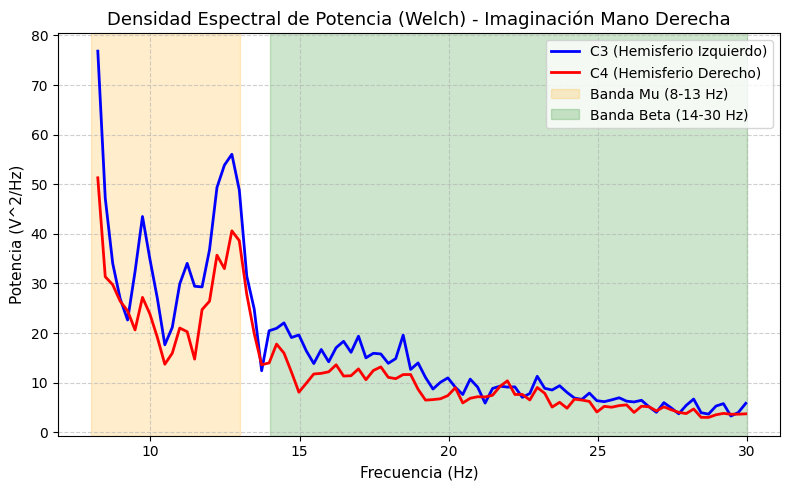

In [ ]:
# Graficar la PSD por Welch de la tarea de Imaginación (Mano Derecha)
fig, ax = plt.subplots(figsize=(8, 5))

# Promediamos la potencia de todos los intentos para que la curva sea más suave
psd_promedio = np.mean(datos_psd, axis=0) 

# Graficamos C3 y C4
ax.plot(frecuencias_psd, psd_promedio[idx_c3], label='C3 (Hemisferio Izquierdo)', color='blue', lw=2)
ax.plot(frecuencias_psd, psd_promedio[idx_c4], label='C4 (Hemisferio Derecho)', color='red', lw=2)

# Resaltamos las bandas Mu y Beta
ax.axvspan(8, 13, color='orange', alpha=0.2, label='Banda Mu (8-13 Hz)')
ax.axvspan(14, 30, color='green', alpha=0.2, label='Banda Beta (14-30 Hz)')

ax.set_title("Densidad Espectral de Potencia (Welch) - Imaginación Mano Derecha", fontsize=13)
ax.set_xlabel("Frecuencia (Hz)", fontsize=11)
ax.set_ylabel("Potencia (V^2/Hz)", fontsize=11)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Bloque 5: Organización de Datos y Estructuración Final

Para concluir el flujo de procesamiento del sujeto piloto, consolidamos todas las características extraídas en un **DataFrame maestro estructurado**. Esta tabla representa el insumo final para cualquier análisis estadístico posterior o para el entrenamiento de modelos de clasificación (Machine Learning).

Cada fila de este dataset corresponde a un **epoch** (un intento de imaginación o reposo) y contiene:
* **Metadatos:** Identificación del sujeto y la tarea realizada.
* **Potencia Espectral (PSD):** Energía en las bandas $\mu$ y $\beta$ para los canales clave (C3, C4, Cz).
* **Conectividad Funcional (Coherencia):** Nivel de sincronización interhemisférica (C3-C4) y con el vértex (C3-Cz, C4-Cz).

In [ ]:
# -----------------------------BLOQUE 5: CONSOLIDACIÓN DE CARACTERÍSTICAS ----------------------------------

# 1. Asegurar la identificación del canal Cz
idx_cz = epochs.ch_names.index('Cz')

# 2. Inicializar contenedores para las nuevas coherencias
num_epochs = len(epochs)
coh_mu_C3Cz = np.zeros(num_epochs)
coh_beta_C3Cz = np.zeros(num_epochs)
coh_mu_C4Cz = np.zeros(num_epochs)
coh_beta_C4Cz = np.zeros(num_epochs)

# 3. Cálculo de Coherencias Restantes (C3-Cz y C4-Cz)
# Usamos los datos segmentados del Bloque 4 (datos_tiempo)
for i in range(num_epochs):
    s_c3 = datos_tiempo[i, idx_c3, :]
    s_c4 = datos_tiempo[i, idx_c4, :]
    s_cz = datos_tiempo[i, idx_cz, :]
    
    # Coherencia C3-Cz
    f, c_c3cz = coherence(s_c3, s_cz, fs=frecuencia_muestreo, nperseg=256)
    coh_mu_C3Cz[i] = np.mean(c_c3cz[(f >= 8) & (f <= 13)])
    coh_beta_C3Cz[i] = np.mean(c_c3cz[(f >= 14) & (f <= 30)])
    
    # Coherencia C4-Cz
    f, c_c4cz = coherence(s_c4, s_cz, fs=frecuencia_muestreo, nperseg=256)
    coh_mu_C4Cz[i] = np.mean(c_c4cz[(f >= 8) & (f <= 13)])
    coh_beta_C4Cz[i] = np.mean(c_c4cz[(f >= 14) & (f <= 30)])

# 4. Construcción del DataFrame Estructurado
df_final = pd.DataFrame({
    # --- METADATOS ---
    'Sujeto': 'S001',
    'Condicion': df_caracteristicas['Nombre_Tarea'], # Tomado del bloque anterior
    
    # --- POTENCIA MU (8-13 Hz) ---
    'Pot_Mu_C3': potencia_mu[:, idx_c3],
    'Pot_Mu_C4': potencia_mu[:, idx_c4],
    'Pot_Mu_Cz': potencia_mu[:, idx_cz],
    
    # --- POTENCIA BETA (14-30 Hz) ---
    'Pot_Beta_C3': potencia_beta[:, idx_c3],
    'Pot_Beta_C4': potencia_beta[:, idx_c4],
    'Pot_Beta_Cz': potencia_beta[:, idx_cz],
    
    # --- COHERENCIA MU ---
    'Coh_Mu_C3_C4': coherencia_mu, # Ya calculada en Bloque 4
    'Coh_Mu_C3_Cz': coh_mu_C3Cz,
    'Coh_Mu_C4_Cz': coh_mu_C4Cz,
    
    # --- COHERENCIA BETA ---
    'Coh_Beta_C3_C4': coherencia_beta, # Ya calculada en Bloque 4
    'Coh_Beta_C3_Cz': coh_beta_C3Cz,
    'Coh_Beta_C4_Cz': coh_beta_C4Cz
})

# 5. Formateo y Visualización
# Redondeamos a 4 decimales para que la tabla sea legible
df_final = df_final.round(4)

print(f"Estructura del DataFrame final: {df_final.shape[0]} registros x {df_final.shape[1]} columnas")
print("\n--- REGISTRO MAESTRO DE CARACTERÍSTICAS (S001) ---")
display(df_final.head(10))

# OPCIONAL: Guardar a CSV para el informe
# df_final.to_csv('Caracteristicas_S001_1sujeto.csv', index=False)

Estructura del DataFrame final: 29 registros x 14 columnas

--- REGISTRO MAESTRO DE CARACTERÍSTICAS (S001) ---


,Sujeto,Condicion,Pot_Mu_C3,Pot_Mu_C4,Pot_Mu_Cz,Pot_Beta_C3,Pot_Beta_C4,Pot_Beta_Cz,Coh_Mu_C3_C4,Coh_Mu_C3_Cz,Coh_Mu_C4_Cz,Coh_Beta_C3_C4,Coh_Beta_C3_Cz,Coh_Beta_C4_Cz
0,S001,Imag_Derecha,34.3297,29.3307,34.8573,8.5900,7.0162,7.4453,0.6279,0.8118,0.7784,0.5471,0.8167,0.6825
1,S001,Reposo,37.1416,22.6331,36.1572,12.7006,8.7473,12.2556,0.7026,0.8694,0.8353,0.6732,0.8443,0.7705
2,S001,Imag_Izquierda,19.6705,18.5123,23.3160,8.9453,5.5855,7.8271,0.6615,0.7831,0.8889,0.6152,0.8278,0.7961
3,S001,Reposo,34.4681,27.3245,31.7585,7.0452,5.9206,7.6296,0.3742,0.7681,0.6580,0.5400,0.7218,0.7267
4,S001,Imag_Izquierda,39.8898,16.4288,29.3853,7.6662,6.1331,7.3900,0.7292,0.8682,0.8654,0.5591,0.7704,0.7879
5,S001,Reposo,35.4693,30.5721,22.8304,8.9487,7.3388,8.5078,0.6191,0.7318,0.8065,0.5656,0.7939,0.7119
6,S001,Imag_Derecha,19.8145,17.3654,19.9710,6.6502,5.9167,6.8988,0.6463,0.8443,0.7888,0.4814,0.7807,0.6766
7,S001,Reposo,58.5259,44.1269,65.9753,10.0965,8.5515,9.7217,0.8347,0.9295,0.9412,0.6385,0.7958,0.8449
8,S001,Imag_Derecha,13.1355,11.1882,13.5397,8.3534,6.7746,8.9199,0.7096,0.8664,0.9031,0.6934,0.8352,0.8120
9,S001,Reposo,27.9849,16.7181,20.5662,6.9617,5.3206,6.5618,0.7447,0.8312,0.8211,0.5202,0.7532,0.7500


In [ ]:
# --------------------- BLOQUE 6: PROCESAMIENTO RUN 3 Y RESUMEN ESTADÍSTICO----------------------------------------

# 1. Cargar y preparar el archivo Run 3
ruta_run3 = 'Sujetos/S001R03.edf' 
raw_real = mne.io.read_raw_edf(ruta_run3, preload=True, verbose=False)
mne.datasets.eegbci.standardize(raw_real)
raw_real.set_montage('standard_1020', match_case=False)

# 2. Filtrado
raw_real.notch_filter(60.0, verbose=False)
raw_real.filter(8.0, 30.0, verbose=False)

# 3. Epoching
eventos_real, eventos_dict_real = mne.events_from_annotations(raw_real, verbose=False)

mapeo_eventos_real = {}
for clave, valor in eventos_dict_real.items():
    if clave == 'T0': mapeo_eventos_real['Reposo'] = valor
    elif clave == 'T1': mapeo_eventos_real['Izquierda'] = valor
    elif clave == 'T2': mapeo_eventos_real['Derecha'] = valor

epochs_real = mne.Epochs(raw_real, eventos_real, event_id=mapeo_eventos_real, 
                         tmin=-0.5, tmax=4.0, baseline=(-0.5, 0), preload=True, verbose=False)

# 4. Extracción de Potencia (Welch) para Run 3
psd_real = epochs_real.compute_psd(method='welch', fmin=8, fmax=30, tmin=0, tmax=4.0, verbose=False)
datos_psd_real = psd_real.get_data() * 1e12 # Escala a microVoltios
freqs_real = psd_real.freqs

pot_mu_real = np.mean(datos_psd_real[:, :, (freqs_real >= 8) & (freqs_real <= 13)], axis=2)

# 5. Extracción de Coherencia para Run 3
datos_tiempo_real = epochs_real.copy().crop(tmin=0, tmax=4.0).get_data(copy=True)
coh_mu_C3C4_real = np.zeros(len(epochs_real))

for i in range(len(epochs_real)):
    f, c = coherence(datos_tiempo_real[i, idx_c3, :], datos_tiempo_real[i, idx_c4, :], fs=frecuencia_muestreo, nperseg=256)
    coh_mu_C3C4_real[i] = np.mean(c[(f >= 8) & (f <= 13)])

# 6. Armar DataFrame Run 3
df_real = pd.DataFrame({
    'Sujeto': 'S001',
    'Condicion': epochs_real.events[:, -1],
    'Tipo': 'Movimiento Real',
    'Pot_Mu_C3': pot_mu_real[:, idx_c3],
    'Pot_Mu_C4': pot_mu_real[:, idx_c4],
    'Coh_Mu_C3_C4': coh_mu_C3C4_real
})

mapa_inverso_real = {v: k for k, v in mapeo_eventos_real.items()}
df_real['Condicion'] = df_real['Condicion'].map(mapa_inverso_real)

# 7. Unir Run 3 y Run 4 en un solo DataFrame
df_final_mod = df_final.copy()
df_final_mod['Condicion'] = df_final_mod['Condicion'].str.replace('Imag_', '') 
df_final_mod['Tipo'] = 'Imaginación Motora'

df_combinado = pd.concat([df_real, df_final_mod[['Sujeto', 'Condicion', 'Tipo', 'Pot_Mu_C3', 'Pot_Mu_C4', 'Coh_Mu_C3_C4']]], ignore_index=True)

# 8. ANÁLISIS ESTADÍSTICO NUMÉRICO

# Agrupamos por el Tipo de tarea (Real vs Imaginada) y la Condición (Reposo, Izquierda, Derecha)
# Calculamos el promedio de la potencia y la coherencia
tabla_resumen = df_combinado.groupby(['Tipo', 'Condicion'])[['Pot_Mu_C3', 'Pot_Mu_C4', 'Coh_Mu_C3_C4']].mean()

# Formateamos para que se vea ordenado a 4 decimales
tabla_resumen = tabla_resumen.round(4)

print("\n--- RESUMEN ESTADÍSTICO DE LATERALIDAD Y CONECTIVIDAD (Promedios) ---")
display(tabla_resumen)

Procesando Run 3 (Movimiento Real)... por favor espera.

--- RESUMEN ESTADÍSTICO DE LATERALIDAD Y CONECTIVIDAD (Promedios) ---


Pot_Mu_C3  Pot_Mu_C4  Coh_Mu_C3_C4
Tipo               Condicion                                    
Imaginación Motora Derecha      25.9744    27.9519        0.6064
                   Izquierda    31.8345    20.1460        0.7070
                   Reposo       46.6804    30.3234        0.6087
Movimiento Real    Derecha      29.3299    31.4437        0.9341
                   Izquierda    33.1117    35.9584        0.9267
                   Reposo       35.0275    40.2455        0.9336

In [ ]:
# Analisis Estadistico hacia abajo, voy a dormir

In [14]:
import os
import numpy as np
import pandas as pd
import mne
from scipy.signal import welch

def procesar_dataset_completo(
    data_path= "Sujetos",
    n_subjects= 109,
    canales= ('C3','C4','CZ'),
    tmin= 1.0,
    tmax= 4.0,
    usar_ica= False,        
    notch_60= True,         # quitar línea eléctrica
    normalizar= True        # z-score por epoch
):
    """
    Función que sigue los pasos de procesamiento de señales EEG definido
    Retorna DataFrame con:
    sujeto, tipo (real/imag), condicion (izq/der), canal, pot_mu, pot_beta, erd_mu, ers_beta
    """

    resultados = []

    # Runs según dataset (ajusta si tu dataset difiere)
    runs_dict = {
        "real": ['R03', 'R07', 'R11'],
        "imag": ['R04', 'R08', 'R12']
    }

    for i in range(1, n_subjects + 1):
        sujeto = f"S{str(i).zfill(3)}"
        print(f"Procesando {sujeto}...")

        for tipo, runs in runs_dict.items():
            for run in runs:

                fname = f"{sujeto}{run}.edf"
                fpath = os.path.join(data_path, fname)

                if not os.path.exists(fpath):
                    # evita romper el pipeline si faltan archivos
                    continue

                # 1) Carga
                raw = mne.io.read_raw_edf(fpath, preload=True, verbose=False)
                raw.rename_channels(lambda x: x.replace('.', '').upper())

                # 2) Preprocesamiento
                # Notch para 60 Hz (ruido de red)
                if notch_60:
                    raw.notch_filter(freqs=[60], verbose=False)

                # Band-pass 5–30 Hz (μ y β)
                raw.filter(5, 30, verbose=False)

                # ICA 
                if usar_ica:
                    ica = mne.preprocessing.ICA(n_components=15, random_state=97, max_iter='auto')
                    ica.fit(raw)
                    raw = ica.apply(raw)

                # 3) Eventos y segmentación
                events, event_id = mne.events_from_annotations(raw)
                canales_disponibles = [ch for ch in raw.ch_names if ch in canales]

                if len(canales_disponibles) < 3:
                    print(f"Canales faltantes en {fname}: {canales_disponibles}")
                    continue

                try:
                    epochs = mne.Epochs(
                        raw,
                        events,
                        event_id= event_id,
                        tmin= tmin,
                        tmax= tmax,
                        picks= canales_disponibles,
                        baseline= None,   # baseline lo usamos luego para ERD/ERS
                        preload= True,
                        verbose= False
                    )

                    if len(epochs) == 0:
                        print(f"Epochs vacíos en {fname}")
                        continue

                    epochs_left  = epochs['T1']
                    epochs_right = epochs['T2']

                except Exception:
                    # si no hay eventos o etiquetas, saltar
                    continue

                condiciones = {
                    "izquierda": epochs_left,
                    "derecha": epochs_right
                }

                fs = raw.info['sfreq']

                # 4) Recorrer epochs y features
                for lado, ep in condiciones.items():

                    data = ep.get_data()  # (n_epochs, n_canales, n_times)

                    # baseline para ERD/ERS: tomamos una ventana inicial corta del mismo epoch
                    n_base = int(0.5 * fs)

                    for epoch in data:
                        for ch_idx, ch_name in enumerate(canales):

                            signal = epoch[ch_idx]

                            # Normalización (z-score por epoch)
                            if normalizar:
                                signal = (signal - np.mean(signal)) / (np.std(signal) + 1e-8)

                            # PSD (Welch)
                            freqs, psd = welch(signal, fs, nperseg=int(fs*2))

                            # Bandas
                            mu_band   = (freqs >= 8)  & (freqs <= 13)
                            beta_band = (freqs >= 14) & (freqs <= 30)

                            pot_mu   = np.mean(psd[mu_band])
                            pot_beta = np.mean(psd[beta_band])

                            # ERD / ERS (respecto a baseline)
                            base_signal = signal[:n_base]
                            freqs_b, psd_b = welch(base_signal, fs, nperseg=min(len(base_signal), int(fs)))

                            # evitar problemas si longitudes difieren
                            # interpolamos psd baseline al eje de freqs
                            psd_b_interp = np.interp(freqs, freqs_b, psd_b)

                            base_mu   = np.mean(psd_b_interp[mu_band]) + 1e-12
                            base_beta = np.mean(psd_b_interp[beta_band]) + 1e-12

                            # ERD (μ): esperamos disminución (valores negativos)
                            erd_mu = (pot_mu - base_mu) / base_mu

                            # ERS (β): a menudo incremento post-movimiento
                            ers_beta = (pot_beta - base_beta) / base_beta

                            resultados.append({
                                "sujeto": sujeto,
                                "tipo": tipo,              # real / imag
                                "condicion": lado,         # izquierda / derecha
                                "canal": ch_name,
                                "pot_mu": pot_mu,
                                "pot_beta": pot_beta,
                                "erd_mu": erd_mu,
                                "ers_beta": ers_beta
                            })

    df = pd.DataFrame(resultados)
    return df

In [15]:
df = procesar_dataset_completo(
    data_path="Sujetos",
    n_subjects=14,
    usar_ica=False,   
    notch_60=True,
    normalizar=True
)

print(df.head())
print(df.shape)

Procesando S001...
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Procesando S002...
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Procesando S003...
Used Annotations de

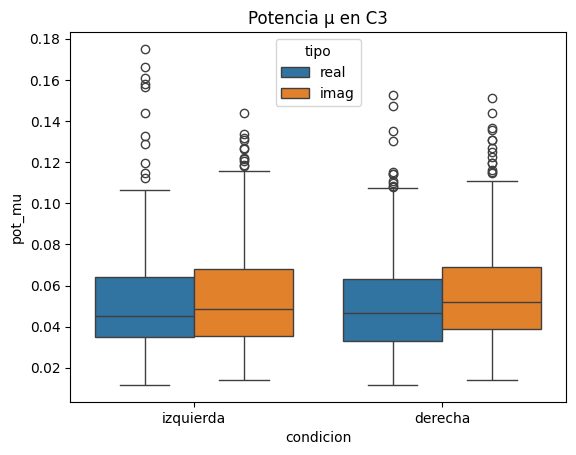

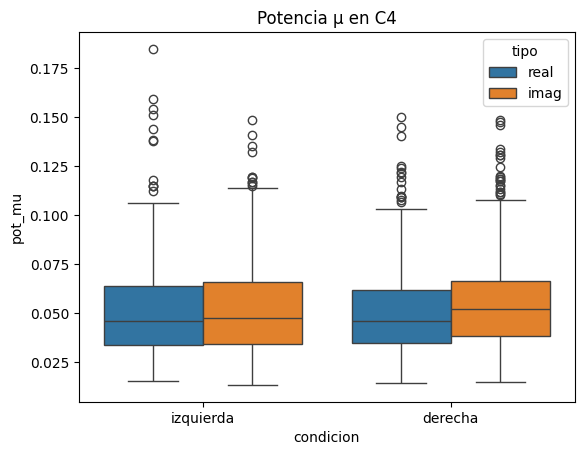

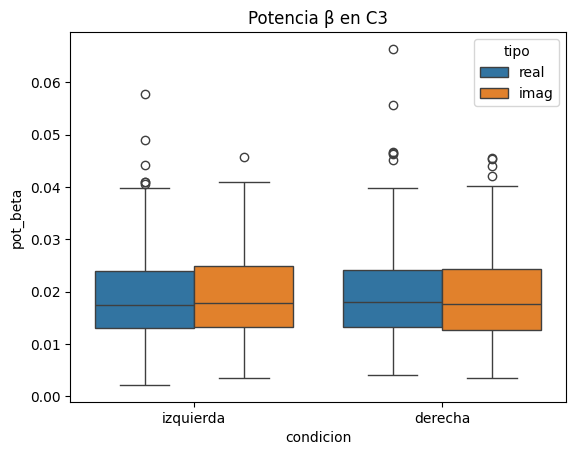

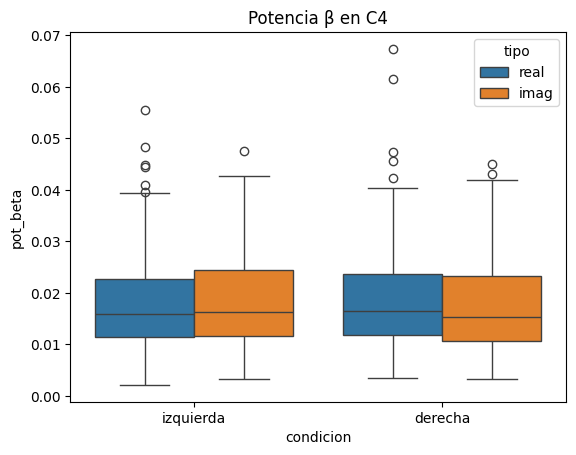

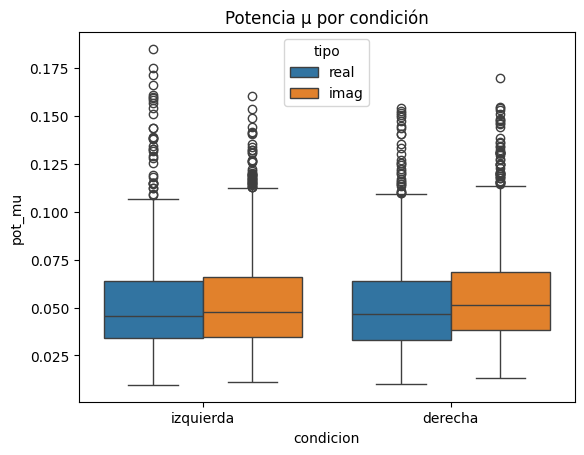

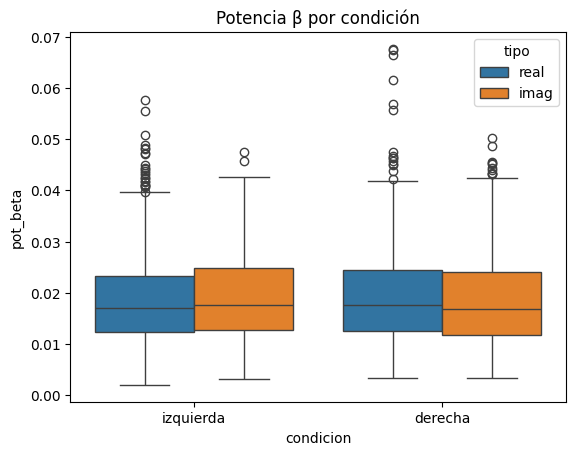

t = -1.9590488563075235
p = 0.0501813986153974
C3 → t: -0.38362434875509194 p: 0.7013224954637147
F = 11.151367628555127
p = 0.0008479371281050976


In [21]:
# Analisis general
df.groupby(['tipo','condicion','canal'])[['pot_mu','pot_beta','erd_mu','ers_beta']].mean()

#Analisis por canal 
df_C3 = df[df["canal"] == "C3"]
df_C4 = df[df["canal"] == "C4"]

# C3 (control mano derecha)
sns.boxplot(data=df_C3, x="condicion", y="pot_mu", hue="tipo")
plt.title("Potencia μ en C3")
plt.show()

# C4 (control mano izquierda)
sns.boxplot(data=df_C4, x="condicion", y="pot_mu", hue="tipo")
plt.title("Potencia μ en C4")
plt.show()

# C3 (control mano derecha)
sns.boxplot(data=df_C3, x="condicion", y="pot_beta", hue="tipo")
plt.title("Potencia β en C3")
plt.show()

# C4 (control mano izquierda)
sns.boxplot(data=df_C4, x="condicion", y="pot_beta", hue="tipo")
plt.title("Potencia β en C4")
plt.show()

# Boxplot μ
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df, x="condicion", y="pot_mu", hue="tipo")
plt.title("Potencia μ por condición")
plt.show()

#Boxplot beta
sns.boxplot(data=df, x="condicion", y="pot_beta", hue="tipo")
plt.title("Potencia β por condición")
plt.show()

#Prueba t
from scipy.stats import ttest_ind
izq = df[df["condicion"]=="izquierda"]["pot_mu"]
der = df[df["condicion"]=="derecha"]["pot_mu"]

t, p = ttest_ind(izq, der)

print("t =", t)
print("p =", p)

#Prueba t por canal 
izq = df_C3[df_C3["condicion"]=="izquierda"]["pot_mu"]
der = df_C3[df_C3["condicion"]=="derecha"]["pot_mu"]

t, p = ttest_ind(izq, der)

print("C3 → t:", t, "p:", p)

#ANOVA 
from scipy.stats import f_oneway
grupo1 = df[df["tipo"]=="real"]["pot_mu"]
grupo2 = df[df["tipo"]=="imag"]["pot_mu"]

f, p = f_oneway(grupo1, grupo2)

print("F =", f)
print("p =", p)
